# AB13_Test.py  — Offline prediction evaluation on AB13

In [122]:
import importlib
import Bayes_Paper_Functions
importlib.reload(Bayes_Paper_Functions)

<module 'Bayes_Paper_Functions' from 'c:\\Users\\fawaz\\Downloads\\Bayes_Paper_Functions.py'>

In [145]:
import sys
import pickle
import numpy as np
import pandas as pd
import sys
import matplotlib.pyplot as plt
sys.path.append(r'C:\Users\fawaz\Downloads')    
sys.path.insert(0, r'C:\Users\fawaz\OneDrive\Documents\Desktop\Research')

from Bayes_Paper_Functions import (
    build_grid, compute_prior, predict_foot_placement,
    FEATURE_NAMES, GRID_RES, OUTPUT_CSV, SUBJECTS, TREADMILL_CSV, detect_gait_events
)

# load trained models

In [146]:
with open(r'C:\Users\fawaz\OneDrive\Documents\Desktop\Research\trained_models_treadmill.pkl', 'rb') as f:
    saved = pickle.load(f)
models, gammas, norm_bounds = saved['models'], saved['gammas'], saved['norm_bounds']

# Build grid once
AP_fine, ML_fine = build_grid(res=GRID_RES)
ap_flat = AP_fine.ravel()
ml_flat = ML_fine.ravel()
n_cells = len(ap_flat)
print(f'Grid: {AP_fine.shape}, {n_cells} cells')

Grid: (101, 71), 7171 cells


## Load CSV

In [147]:
df = pd.read_csv(TREADMILL_CSV)
print(f'Loaded {len(df)} steps')

Loaded 11761 steps


## Evaluation function

- Accepts a subject ID and optional trial filters.
- Computes predictions for selected steps.
- Reports errors in cm.

In [148]:
def evaluate_subject(subject: str,
                     direction: str = None,
                     speed: str = None,
                     leg: str = None,
                     random_seed: int = None):

    subj_df = df[df['subject'] == subject].copy()
    if len(subj_df) == 0:
        print(f'No data for subject {subject}.')
        return

    def run_trial(trial_df):
        """Run predictions with prior on one trial, return error arrays."""
        prev_xg, prev_yg = [], []
        errs_x, errs_y, errs_d = [], [], []
        for _, row in trial_df.iterrows():
            if len(prev_xg) >= 2:
                xh = np.mean(prev_xg[-2:])
                yh = np.mean(prev_yg[-2:])
                prior = compute_prior(ap_flat, ml_flat, xh, yh)
            else:
                prior = None
            xp, yp = predict_foot_placement(row, models, norm_bounds, gammas,
                                            ap_flat, ml_flat, prior=prior)
            prev_xg.append(row['xg'])
            prev_yg.append(row['yg'])
            errs_x.append((xp - row['xg']) * 100)
            errs_y.append((yp - row['yg']) * 100)
            errs_d.append(np.sqrt((xp - row['xg'])**2 + (yp - row['yg'])**2) * 100)
        return np.array(errs_x), np.array(errs_y), np.array(errs_d)

    def print_metrics(errors_x, errors_y, errors_d):
        print(f'  RMSE x:       {np.sqrt(np.mean(errors_x**2)):.2f} cm')
        print(f'  RMSE y:       {np.sqrt(np.mean(errors_y**2)):.2f} cm')
        print(f'  RMSE distance:{np.sqrt(np.mean(errors_d**2)):.2f} cm')
        print(f'  Mean error x: {np.mean(errors_x):.2f} cm')
        print(f'  Mean error y: {np.mean(errors_y):.2f} cm')
        print(f'  MSE x:        {np.mean(errors_x**2):.2f} cm²')
        print(f'  MSE y:        {np.mean(errors_y**2):.2f} cm²')
        print(f'  Mean absolute distance error: {np.mean(errors_d):.2f} cm')

    # ── Single trial ─────────────────────────────────────────────────────────
    if direction is not None and speed is not None and leg is not None:
        trial_df = subj_df[(subj_df['direction'] == direction) &
                           (subj_df['speed'] == speed) &
                           (subj_df['leg'] == leg)]
        if len(trial_df) == 0:
            print(f'No trial: {direction} {speed} {leg}')
            return

        print(f'\n=== Single trial: {direction} {speed} leg {leg} ===')
        print(f'Total steps in trial: {len(trial_df)}')

        if random_seed is not None:
            np.random.seed(random_seed)
        rand_idx = np.random.randint(len(trial_df))
        step = trial_df.iloc[rand_idx]

        # prior for sample step
        prior_step = None
        if rand_idx >= 2:
            xh = trial_df.iloc[rand_idx-2:rand_idx]['xg'].mean()
            yh = trial_df.iloc[rand_idx-2:rand_idx]['yg'].mean()
            prior_step = compute_prior(ap_flat, ml_flat, xh, yh)

        xp, yp = predict_foot_placement(step, models, norm_bounds, gammas,
                                        ap_flat, ml_flat, prior=prior_step)
        print(f'\nRandom step index (in trial): {rand_idx}')
        print(f'  Ground truth: x={step["xg"]*100:.1f} cm, y={step["yg"]*100:.1f} cm')
        print(f'  Predicted:    x={xp*100:.1f} cm, y={yp*100:.1f} cm')
        print(f'  Distance error: {np.sqrt((xp-step["xg"])**2+(yp-step["yg"])**2)*100:.1f} cm')

        errors_x, errors_y, errors_d = run_trial(trial_df)
        print('\nTrial metrics:')
        print_metrics(errors_x, errors_y, errors_d)

    # ── All trials ────────────────────────────────────────────────────────────
    else:
        print(f'\n=== All trials for subject {subject} ===')
        print(f'Total steps: {len(subj_df)}')

        all_x, all_y, all_d = [], [], []
        for (d, s, l), grp in subj_df.groupby(['direction', 'speed', 'leg']):
            ex, ey, ed = run_trial(grp)
            all_x.extend(ex); all_y.extend(ey); all_d.extend(ed)

        print('\nOverall metrics (all trials combined):')
        print_metrics(np.array(all_x), np.array(all_y), np.array(all_d))

        trials = subj_df.groupby(['direction','speed','leg']).size()
        if len(trials) > 1:
            print('\nPer-trial breakdown:')
            for (d, s, l), grp in subj_df.groupby(['direction','speed','leg']):
                ex, ey, ed = run_trial(grp)
                ex, ey, ed = np.array(ex), np.array(ey), np.array(ed)
                print(f'  {d:4s} {s:6s} {l}: n={len(grp):3d}  '
                      f'RMSE_x={np.sqrt(np.mean(ex**2)):5.2f} cm  '
                      f'RMSE_y={np.sqrt(np.mean(ey**2)):5.2f} cm  '
                      f'RMSE_dist={np.sqrt(np.mean(ed**2)):5.2f} cm')

## Example 1: Single trial with a random step

In [149]:
# Evaluate the slow clockwise trial for AB13, right leg
evaluate_subject('AB13', direction='cw', speed='slow', leg='R', random_seed=5)

No trial: cw slow R


## Example 2: All AB13 steps (no trial filter)

In [150]:
evaluate_subject('AB13')


=== All trials for subject AB13 ===
Total steps: 1320

Overall metrics (all trials combined):
  RMSE x:       9.11 cm
  RMSE y:       3.35 cm
  RMSE distance:9.70 cm
  Mean error x: -1.52 cm
  Mean error y: -0.97 cm
  MSE x:        82.91 cm²
  MSE y:        11.20 cm²
  Mean absolute distance error: 8.25 cm

Per-trial breakdown:
  treadmill 01_01  L: n=127  RMSE_x= 7.74 cm  RMSE_y= 2.98 cm  RMSE_dist= 8.29 cm
  treadmill 01_01  R: n= 18  RMSE_x=15.88 cm  RMSE_y= 2.56 cm  RMSE_dist=16.08 cm
  treadmill 02_01  L: n=129  RMSE_x= 6.96 cm  RMSE_y= 3.33 cm  RMSE_dist= 7.72 cm
  treadmill 02_01  R: n= 31  RMSE_x=13.24 cm  RMSE_y= 4.38 cm  RMSE_dist=13.95 cm
  treadmill 03_01  L: n=130  RMSE_x= 6.20 cm  RMSE_y= 3.56 cm  RMSE_dist= 7.15 cm
  treadmill 03_01  R: n= 53  RMSE_x=12.41 cm  RMSE_y= 3.27 cm  RMSE_dist=12.84 cm
  treadmill 04_01  L: n=131  RMSE_x= 7.30 cm  RMSE_y= 3.20 cm  RMSE_dist= 7.97 cm
  treadmill 04_01  R: n= 71  RMSE_x= 6.99 cm  RMSE_y= 3.82 cm  RMSE_dist= 7.96 cm
  treadmill 0

                xg           yg
count  1320.000000  1320.000000
mean      0.776666    -0.000689
std       0.141199     0.027500
min       0.434242    -0.142752
25%       0.667527    -0.018579
50%       0.781166     0.000186
75%       0.888900     0.017312
max       1.196942     0.109073
[[<Axes: title={'center': 'xg'}> <Axes: title={'center': 'yg'}>]]


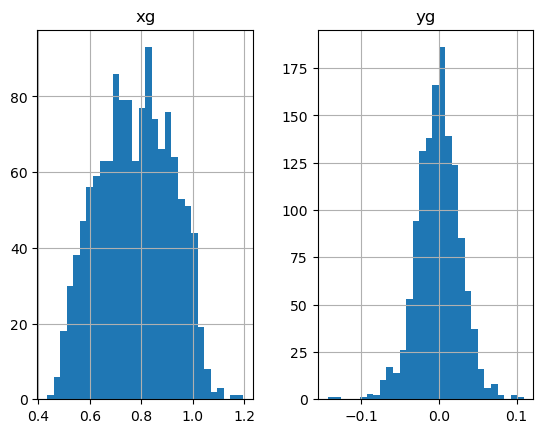

In [151]:
ab13 = df[df['subject'] == 'AB13']
print(ab13[['xg', 'yg']].describe())
print(ab13[['xg', 'yg']].hist(bins=30))

In [152]:
for subj in df['subject'].unique():
    sub = df[df['subject'] == subj]
    print(f'{subj}: xg mean={sub["xg"].mean():.3f} std={sub["xg"].std():.3f} | '
          f'yg mean={sub["yg"].mean():.3f} std={sub["yg"].std():.3f}')

AB06: xg mean=0.841 std=0.147 | yg mean=-0.002 std=0.018
AB07: xg mean=0.886 std=0.164 | yg mean=0.007 std=0.020
AB08: xg mean=0.812 std=0.154 | yg mean=-0.001 std=0.021
AB09: xg mean=0.839 std=0.146 | yg mean=0.003 std=0.022
AB10: xg mean=0.793 std=0.130 | yg mean=0.002 std=0.021
AB11: xg mean=0.803 std=0.126 | yg mean=0.001 std=0.026
AB12: xg mean=0.804 std=0.181 | yg mean=0.003 std=0.024
AB13: xg mean=0.777 std=0.141 | yg mean=-0.001 std=0.028


In [153]:
for subj in ['AB06']:
    evaluate_subject(subj)


=== All trials for subject AB06 ===
Total steps: 1831

Overall metrics (all trials combined):
  RMSE x:       10.29 cm
  RMSE y:       2.24 cm
  RMSE distance:10.53 cm
  Mean error x: -5.28 cm
  Mean error y: -0.20 cm
  MSE x:        105.79 cm²
  MSE y:        5.03 cm²
  Mean absolute distance error: 8.41 cm

Per-trial breakdown:
  treadmill 01_01  L: n=122  RMSE_x= 4.81 cm  RMSE_y= 1.61 cm  RMSE_dist= 5.07 cm
  treadmill 01_01  R: n= 89  RMSE_x= 7.92 cm  RMSE_y= 3.46 cm  RMSE_dist= 8.64 cm
  treadmill 02_01  L: n=127  RMSE_x= 4.79 cm  RMSE_y= 1.45 cm  RMSE_dist= 5.01 cm
  treadmill 02_01  R: n= 77  RMSE_x= 6.07 cm  RMSE_y= 2.98 cm  RMSE_dist= 6.76 cm
  treadmill 03_01  L: n=129  RMSE_x= 6.59 cm  RMSE_y= 1.51 cm  RMSE_dist= 6.76 cm
  treadmill 03_01  R: n= 97  RMSE_x= 5.62 cm  RMSE_y= 3.56 cm  RMSE_dist= 6.65 cm
  treadmill 04_01  L: n=131  RMSE_x= 8.32 cm  RMSE_y= 1.37 cm  RMSE_dist= 8.43 cm
  treadmill 04_01  R: n=100  RMSE_x= 4.94 cm  RMSE_y= 3.34 cm  RMSE_dist= 5.96 cm
  treadmill

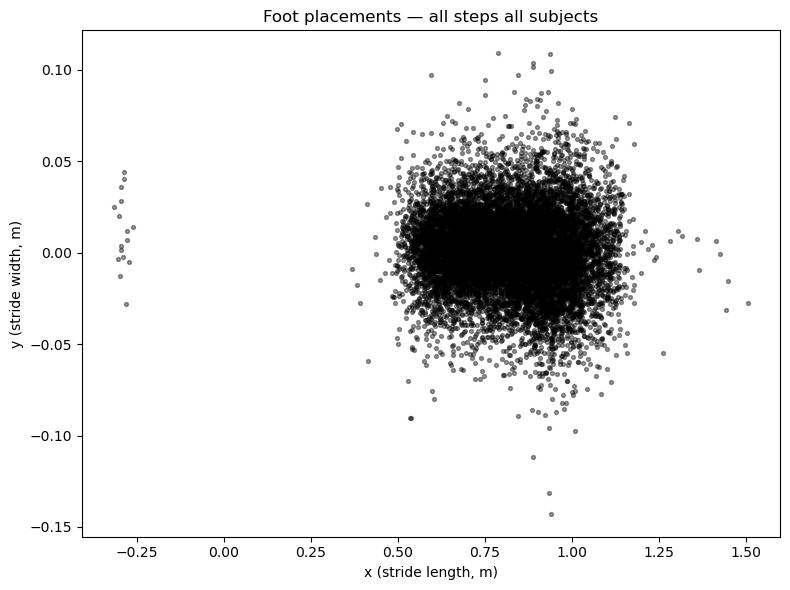

In [154]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df['xg'], df['yg'], s=8, alpha=0.4, c='black')
ax.set_xlabel('x (stride length, m)')
ax.set_ylabel('y (stride width, m)')
ax.set_title('Foot placements — all steps all subjects')
plt.tight_layout()
plt.show()

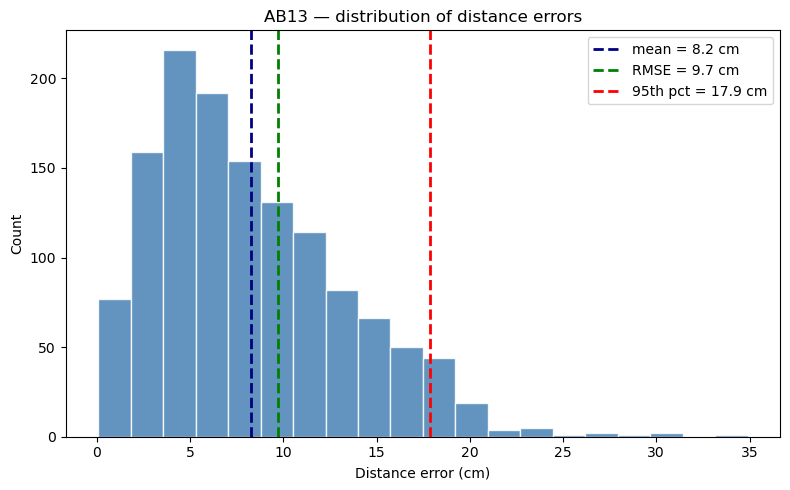

In [155]:
import matplotlib.pyplot as plt
import numpy as np

# collect all distance errors for AB13
all_errors_d = []
for (d, s, l), grp in df[df['subject'] == 'AB13'].groupby(['direction', 'speed', 'leg']):
    prev_xg, prev_yg = [], []
    for _, row in grp.iterrows():
        if len(prev_xg) >= 2:
            xh = np.mean(prev_xg[-2:])
            yh = np.mean(prev_yg[-2:])
            prior = compute_prior(ap_flat, ml_flat, xh, yh)
        else:
            prior = None
        xp, yp = predict_foot_placement(row, models, norm_bounds, gammas,
                                        ap_flat, ml_flat, prior=prior)
        prev_xg.append(row['xg'])
        prev_yg.append(row['yg'])
        all_errors_d.append(np.sqrt((xp - row['xg'])**2 + (yp - row['yg'])**2) * 100)

all_errors_d = np.array(all_errors_d)
p95 = np.percentile(all_errors_d, 95)
mean = np.mean(all_errors_d)
rmse = np.sqrt(np.mean(all_errors_d**2))

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(all_errors_d, bins=20, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(mean, color='navy',  lw=2, linestyle='--', label=f'mean = {mean:.1f} cm')
ax.axvline(rmse, color='green', lw=2, linestyle='--', label=f'RMSE = {rmse:.1f} cm')
ax.axvline(p95,  color='red',   lw=2, linestyle='--', label=f'95th pct = {p95:.1f} cm')
ax.set_xlabel('Distance error (cm)')
ax.set_ylabel('Count')
ax.set_title('AB13 — distribution of distance errors')
ax.legend()
plt.tight_layout()
plt.show()

In [157]:
# More steps in 30s trial ≈ faster walking (higher cadence)
print(df.groupby(['subject', 'speed'])['fA'].count().unstack('speed'))

speed    01_01  02_01  03_01  04_01  05_01  06_01  07_01  08_01
subject                                                        
AB06     211.0  204.0  226.0  231.0  238.0  239.0  237.0  245.0
AB07     195.0  192.0  190.0  219.0  213.0  224.0  232.0  249.0
AB08     149.0  138.0  158.0  182.0  169.0  174.0  170.0    NaN
AB09     202.0  223.0  219.0  238.0  237.0  247.0  252.0    NaN
AB10     145.0  159.0  185.0  173.0  193.0  199.0  224.0    NaN
AB11     211.0  220.0  226.0  211.0  214.0  224.0  243.0    NaN
AB12     180.0  158.0  170.0  182.0  187.0  220.0  214.0    NaN
AB13     145.0  160.0  183.0  202.0  207.0  219.0  204.0    NaN
